In [1]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

analyzer = SentimentIntensityAnalyzer()

examples = [
    "This phone is absolutely AMAZING!!!",
    "The battery life is terrible and disappointing.",
    "It's okay. Not the best, not the worst.",
    "Siri is so frustrating, it never understands me.",
    "Google Assistant works perfectly every single time!"
]

print("VADER scores (compound is the overall score, -1 to +1):\n")
for text in examples:
    scores = analyzer.polarity_scores(text)
    print(f"Text: {text[:60]}")
    print(f"  Scores: {scores}")
    print()

VADER scores (compound is the overall score, -1 to +1):

Text: This phone is absolutely AMAZING!!!
  Scores: {'neg': 0.0, 'neu': 0.412, 'pos': 0.588, 'compound': 0.7719}

Text: The battery life is terrible and disappointing.
  Scores: {'neg': 0.558, 'neu': 0.442, 'pos': 0.0, 'compound': -0.743}

Text: It's okay. Not the best, not the worst.
  Scores: {'neg': 0.248, 'neu': 0.369, 'pos': 0.383, 'compound': 0.2086}

Text: Siri is so frustrating, it never understands me.
  Scores: {'neg': 0.348, 'neu': 0.652, 'pos': 0.0, 'compound': -0.5777}

Text: Google Assistant works perfectly every single time!
  Scores: {'neg': 0.0, 'neu': 0.572, 'pos': 0.428, 'compound': 0.6696}



In [2]:
df = pd.read_csv(
    "/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/processed/master_clean.csv",
    low_memory=False
)
print(f"Loaded {len(df):,} reviews")

print("Scoring sentiment... (takes 3-7 minutes)")

scores = df['review_vader'].apply(
    lambda text: analyzer.polarity_scores(str(text)) if pd.notna(text) 
    else {'compound': 0, 'pos': 0, 'neu': 0, 'neg': 0}
)

df['vader_compound'] = scores.apply(lambda x: x['compound'])
df['vader_pos']      = scores.apply(lambda x: x['pos'])
df['vader_neu']      = scores.apply(lambda x: x['neu'])
df['vader_neg']      = scores.apply(lambda x: x['neg'])

def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['vader_compound'].apply(classify_sentiment)

print("Sentiment distribution:")
print(df['sentiment'].value_counts())
print(f"\nMean compound score: {df['vader_compound'].mean():.3f}")

Loaded 124,108 reviews
Scoring sentiment... (takes 3-7 minutes)
Sentiment distribution:
sentiment
Positive    85893
Negative    26068
Neutral     12147
Name: count, dtype: int64

Mean compound score: 0.384


Sentiment % by brand:
sentiment  Negative  Neutral  Positive
brand                                 
Apple          22.0     11.7      66.3
Google         24.3      6.8      68.9
Huawei         14.5      9.5      76.0
LG             21.9      8.8      69.4
Motorola       21.8      8.8      69.4
Nokia          20.9      8.1      71.0
OnePlus        15.4      6.6      78.1
Samsung        21.0      9.9      69.2
Xiaomi         15.7     16.7      67.6


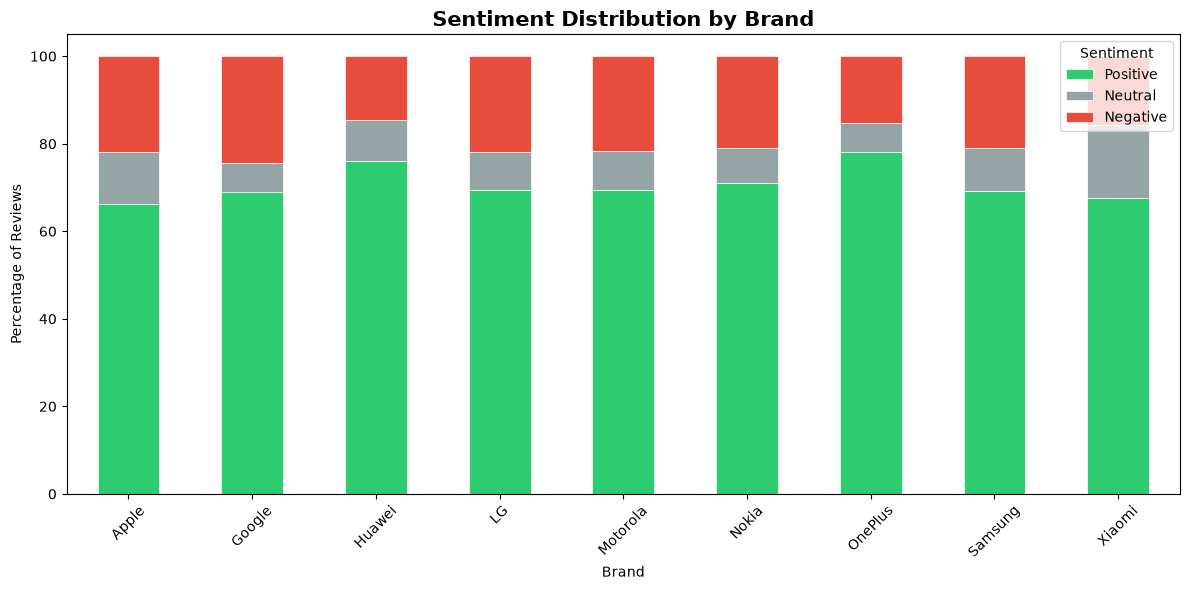

In [3]:
brand_sentiment = df.groupby(['brand', 'sentiment']).size().unstack(fill_value=0)
brand_pct = brand_sentiment.div(brand_sentiment.sum(axis=1), axis=0) * 100

print("Sentiment % by brand:")
print(brand_pct.round(1))

fig, ax = plt.subplots(figsize=(12, 6))
brand_pct[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2ecc71', '#95a5a6', '#e74c3c'],
    edgecolor='white', linewidth=0.5
)
ax.set_title('Sentiment Distribution by Brand', fontsize=15, fontweight='bold')
ax.set_xlabel('Brand')
ax.set_ylabel('Percentage of Reviews')
ax.legend(title='Sentiment', loc='upper right')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/03_sentiment_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()

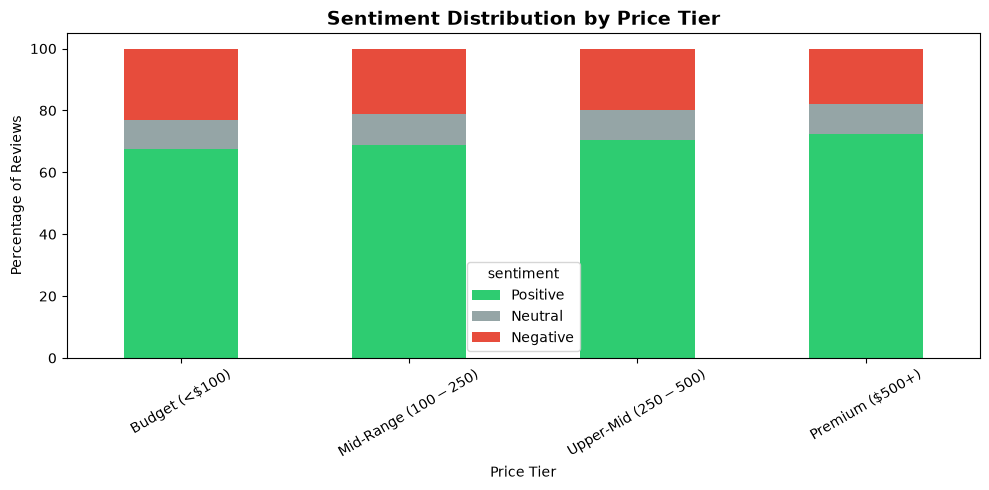


Mean VADER score by price tier:
price_tier
Budget (<$100)           0.355
Mid-Range ($100-$250)    0.380
Premium ($500+)          0.426
Upper-Mid ($250-$500)    0.404
Name: vader_compound, dtype: float64


In [4]:
price_sentiment = df[df['price_tier'] != 'Unknown'].groupby(
    ['price_tier', 'sentiment']
).size().unstack(fill_value=0)

price_pct = price_sentiment.div(price_sentiment.sum(axis=1), axis=0) * 100

TIER_ORDER = ['Budget (<$100)', 'Mid-Range ($100-$250)', 'Upper-Mid ($250-$500)', 'Premium ($500+)']

fig, ax = plt.subplots(figsize=(10, 5))
price_pct.loc[TIER_ORDER, ['Positive', 'Neutral', 'Negative']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2ecc71', '#95a5a6', '#e74c3c']
)
ax.set_title('Sentiment Distribution by Price Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('Price Tier')
ax.set_ylabel('Percentage of Reviews')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/03_sentiment_by_price_tier.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMean VADER score by price tier:")
print(df[df['price_tier'] != 'Unknown'].groupby('price_tier')['vader_compound'].mean().round(3))

In [10]:
FEATURE_KEYWORDS = {
    'voice_assistant': [
        'siri', 'google assistant', 'bixby', 'alexa',
        'hey siri', 'hey google', 'voice command', 'voice control'
    ],
    'biometric': [
        'fingerprint', 'face id', 'face unlock', 'face recognition',
        'touch id', 'biometric'
    ],
    'camera_ai': [
        'ai camera', 'night mode', 'portrait mode', 'night sight',
        'ai photo', 'google lens', 'smart camera'
    ],
    'battery': [
        'battery life', 'fast charging', 'wireless charging',
        'battery drain', 'battery last', 'charge'
    ],
    'display': [
        'amoled', 'oled', 'lcd', 'screen', 'display',
        'resolution', 'brightness', 'retina'
    ],
    'performance': [
        'processor', 'fast', 'slow', 'lag', 'speed',
        'performance', 'snapdragon', 'freeze', 'crash'
    ]
}
for category in FEATURE_KEYWORDS:
    col_name = f'mentions_{category}'
    df[col_name] = df['review_body'].apply(
        lambda text: 1 if any(kw in str(text).lower() 
        for kw in FEATURE_KEYWORDS[category]) else 0
    )
feature_cols = [c for c in df.columns if c.startswith('mentions_')]
print("Feature mention counts across all reviews:")
print(df[feature_cols].sum().sort_values(ascending=False))

Feature mention counts across all reviews:
mentions_battery            19338
mentions_display            18727
mentions_performance        18214
mentions_biometric           2179
mentions_voice_assistant      593
mentions_camera_ai            141
dtype: int64


        feature  reviews_with_mention  avg_sentiment_WITH  avg_sentiment_WITHOUT  difference
        battery                 19338               0.407                  0.380       0.026
        display                 18727               0.469                  0.369       0.099
voice_assistant                   593               0.547                  0.384       0.164
    performance                 18214               0.552                  0.355       0.197
      biometric                  2179               0.643                  0.380       0.263
      camera_ai                   141               0.793                  0.384       0.409


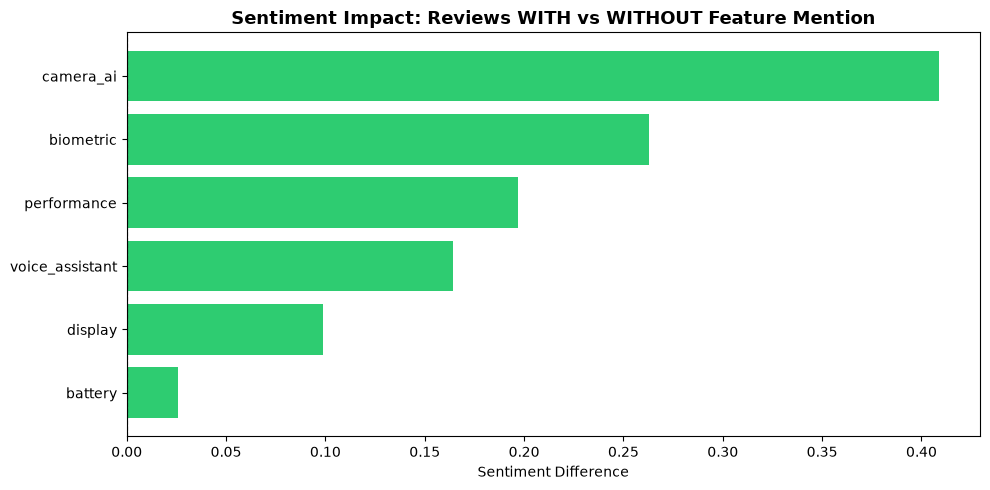

In [12]:
results = []
for col in feature_cols:
    feature_name = col.replace('mentions_', '')
    with_feature = df[df[col] == 1]['vader_compound'].mean()
    without_feature = df[df[col] == 0]['vader_compound'].mean()
    count = df[col].sum()
    results.append({
        'feature': feature_name,
        'reviews_with_mention': int(count),
        'avg_sentiment_WITH': round(with_feature, 3),
        'avg_sentiment_WITHOUT': round(without_feature, 3),
        'difference': round(with_feature - without_feature, 3)
    })

results_df = pd.DataFrame(results).sort_values('difference')
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if d < 0 else '#2ecc71' for d in results_df['difference']]
ax.barh(results_df['feature'], results_df['difference'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Sentiment Impact: Reviews WITH vs WITHOUT Feature Mention', fontsize=13, fontweight='bold')
ax.set_xlabel('Sentiment Difference')
plt.tight_layout()
plt.savefig('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/03_feature_sentiment_impact.png', dpi=150, bbox_inches='tight')
plt.show()

Voice assistant sentiment:
                   mean  count
assistant                     
Bixby             0.347    174
Google Assistant  0.709    106
Other Voice       0.614    150
Siri              0.595    163


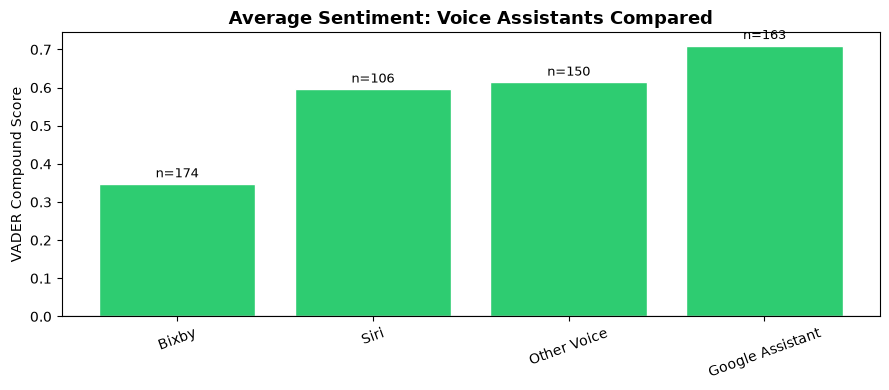

In [14]:
va_df = df[df['mentions_voice_assistant'] == 1].copy()

def label_assistant(text):
    t = str(text).lower()
    if 'google assistant' in t or 'hey google' in t:
        return 'Google Assistant'
    if 'siri' in t or 'hey siri' in t:
        return 'Siri'
    if 'bixby' in t:
        return 'Bixby'
    return 'Other Voice'

va_df['assistant'] = va_df['review_body'].apply(label_assistant)

print("Voice assistant sentiment:")
va_stats = va_df.groupby('assistant')['vader_compound'].agg(['mean', 'count']).round(3)
print(va_stats)

fig, ax = plt.subplots(figsize=(9, 4))
va_mean = va_df.groupby('assistant')['vader_compound'].mean().sort_values()
va_counts = va_df.groupby('assistant').size()
colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in va_mean.values]
bars = ax.bar(va_mean.index, va_mean.values, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Sentiment: Voice Assistants Compared', fontsize=13, fontweight='bold')
ax.set_ylabel('VADER Compound Score')
ax.tick_params(axis='x', rotation=20)
for bar, (asst, count) in zip(bars, va_counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'n={count}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/03_voice_assistant_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
df.to_csv("/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/processed/master_sentiment.csv", index=False)
print(f"Saved {len(df):,} rows with sentiment scores and feature flags")
print(f"\nNew columns added:")
new_cols = ['vader_compound', 'vader_pos', 'vader_neu', 'vader_neg', 'sentiment'] + feature_cols
print(new_cols)

Saved 124,108 rows with sentiment scores and feature flags

New columns added:
['vader_compound', 'vader_pos', 'vader_neu', 'vader_neg', 'sentiment', 'mentions_voice_assistant', 'mentions_biometric', 'mentions_camera_ai', 'mentions_battery', 'mentions_display', 'mentions_performance']


In [19]:
df.to_csv("/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/processed/master_sentiment.csv", index=False)
print(f"Saved {len(df):,} rows with sentiment scores and feature flags")
print(f"\nNew columns added:")
new_cols = ['vader_compound', 'vader_pos', 'vader_neu', 'vader_neg', 'sentiment'] + feature_cols
print(new_cols)

Saved 124,108 rows with sentiment scores and feature flags

New columns added:
['vader_compound', 'vader_pos', 'vader_neu', 'vader_neg', 'sentiment', 'mentions_voice_assistant', 'mentions_biometric', 'mentions_camera_ai', 'mentions_battery', 'mentions_display', 'mentions_performance']
